In [413]:
import numpy as np
import matplotlib.pyplot as plt

In [414]:
def mse(ypred, y):
    return np.sum((ypred-y)**2)

In [415]:
def sig(x):
    return 1 / (1 + np.exp(-x))

In [416]:
def str_to_arr(word):
    sz = len(word)
    arr = np.zeros((sz,1))
    for i in range(sz):
        if word[i]=='1':
            arr[i][0] = 1
    return arr

In [417]:
def str_arr_3d(x):
    ans = []
    for xi in x:
        ans.append(str_to_arr(xi))
    ans = np.array(ans)
    return ans

In [418]:
class NN:

    def __init__(self, in_sz, out_sz, epochs, lr):
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.epochs = epochs
        self.lr = lr
        self.errors = []

    def fit(self, Xtrain, Ytrain):

        np.random.seed(4)
        self.w = np.random.rand(self.in_sz, 1)
        self.b = np.random.randint(0,10)

        samples = Xtrain.shape[0]
        
        for epoch in range(self.epochs):
            wx = np.matmul(self.w.T, Xtrain).reshape(samples,1) + self.b
            wx = wx.reshape(samples,1)
            ypred = sig(wx)
            coeffs = (ypred - Ytrain) * ypred * (1 - ypred)
            Xtrainflat = Xtrain.reshape(samples, self.in_sz)
            del_w = np.matmul(coeffs.T, Xtrainflat)
            self.w -= del_w.T * self.lr
            self.b -= np.sum(coeffs) * self.lr
            self.errors.append(mse(ypred, Ytrain))
            if epoch%(self.epochs/10) == 0:
                print("Error at epoch ", epoch, " = ", mse(ypred, Ytrain))

    def predict(self, x):
        return sig(np.matmul(self.w.T, x) + self.b)

    def accuracy(self, ypred, y):
        diff = np.abs(ypred.reshape(-1) - y.reshape(-1))
        count = len(diff[diff < 0.01])
        return count * 100 / len(y)

    def predict_compare(self, x, y):
        ypred = self.predict(x)
        return self.accuracy(ypred, y)

    def plot(self):
        plt.plot(range(self.epochs), self.errors, color='r')
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.show()

In [419]:
Xtrain_xor = str_arr_3d(["00", "01", "10", "11"])
Ytrain_xor = str_to_arr("0110")

xor_nn = NN(2,1,100000,50)
xor_nn.fit(Xtrain_xor, Ytrain_xor)
print("Accuracy on the training data: ", xor_nn.predict_compare(Xtrain_xor, Ytrain_xor))

Error at epoch  0  =  1.4361753428874926
Error at epoch  10000  =  1.0000022595550586
Error at epoch  20000  =  1.0000015565013676
Error at epoch  30000  =  1.0000011879234465
Error at epoch  40000  =  1.000000960644943
Error at epoch  50000  =  1.000000806515439
Error at epoch  60000  =  1.0000006951418035
Error at epoch  70000  =  1.0000006109193316
Error at epoch  80000  =  1.0000005450128373
Error at epoch  90000  =  1.0000004920450247
Accuracy on the training data:  75.0


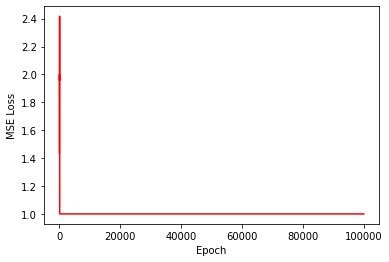

In [420]:
xor_nn.plot()

In [421]:
Xtrain_pal4 = str_arr_3d(["0000", "0001", "0010", "0011", "0100", "0101", "0110", "0111", "1000", "1001", "1010", "1011", "1100", "1101", "1110", "1111"])
Ytrain_pal4 = str_to_arr("1000001001000001")

pal4_nn = NN(4,1,100000,10)
pal4_nn.fit(Xtrain_pal4, Ytrain_pal4)
print("Accuracy on the training data: ", pal4_nn.predict_compare(Xtrain_pal4, Ytrain_pal4))

Error at epoch  0  =  11.251676272526385
Error at epoch  10000  =  3.0003832624489704
Error at epoch  20000  =  3.000070547403106
Error at epoch  30000  =  3.0000387315796284
Error at epoch  40000  =  3.0000266751768185
Error at epoch  50000  =  3.0000203370333054
Error at epoch  60000  =  3.000016430087348
Error at epoch  70000  =  3.000013781094297
Error at epoch  80000  =  3.0000118669701505
Error at epoch  90000  =  3.000010419281683
Accuracy on the training data:  81.25


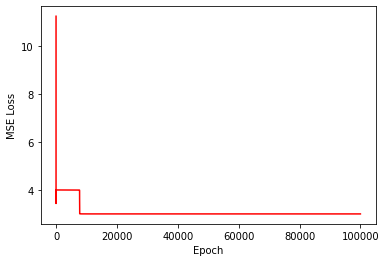

In [422]:
pal4_nn.plot()

In [423]:
Xtrain_pal5 = str_arr_3d(["00000", "00001", "00010", "00011", "00100", "00101", "00110", "00111", "01000", "01001", "01010", "01011", "01100", "01101", "01110", "01111", "10000", "10001", "10010", "10011", "10100", "10101", "10110", "10111", "11000", "11001", "11010", "11011", "11100", "11101", "11110", "11111"])
Ytrain_pal5 = str_to_arr("10001000001000100100010000010001")

pal5_nn = NN(5,1,100000,10)
pal5_nn.fit(Xtrain_pal5, Ytrain_pal5)
print("Accuracy on the training data: ", pal5_nn.predict_compare(Xtrain_pal5, Ytrain_pal5))

Error at epoch  0  =  23.991625816812565
Error at epoch  10000  =  6.0000866817865575
Error at epoch  20000  =  6.000043086165485
Error at epoch  30000  =  6.0000286503017275
Error at epoch  40000  =  6.000021455047623
Error at epoch  50000  =  6.000017146309126
Error at epoch  60000  =  6.000014277734278
Error at epoch  70000  =  6.000012230850546
Error at epoch  80000  =  6.000010696924765
Error at epoch  90000  =  6.000009504653532
Accuracy on the training data:  81.25


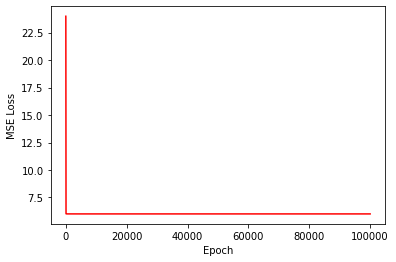

In [424]:
pal5_nn.plot()

In [425]:
Xtrain_maj4 = str_arr_3d(["0000", "0001", "0010", "0011", "0100", "0101", "0110", "0111", "1000", "1001", "1010", "1011", "1100", "1101", "1110", "1111"])
Ytrain_maj4 = str_to_arr("0000000100010111")

maj4_nn = NN(4,1,10000,5)
maj4_nn.fit(Xtrain_maj4, Ytrain_maj4)

print("Accuracy on the training data: ", maj4_nn.predict_compare(Xtrain_maj4, Ytrain_maj4))

Error at epoch  0  =  10.005036293933244
Error at epoch  1000  =  0.0041162192621939635
Error at epoch  2000  =  0.002088830778679336
Error at epoch  3000  =  0.0013959259516953186
Error at epoch  4000  =  0.0010471493975211157
Error at epoch  5000  =  0.0008373798897108785
Error at epoch  6000  =  0.0006974113514703843
Error at epoch  7000  =  0.000597412541800125
Error at epoch  8000  =  0.0005224210958321702
Error at epoch  9000  =  0.00046410955630138266
Accuracy on the training data:  100.0


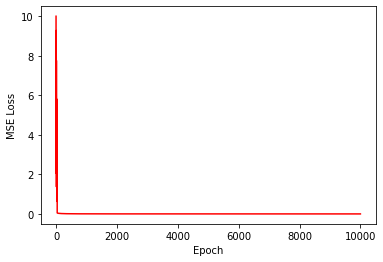

In [426]:
maj4_nn.plot()

In [427]:
Xtrain_maj5 = str_arr_3d(["00000", "00001", "00010", "00011", "00100", "00101", "00110", "00111", "01000", "01001", "01010", "01011", "01100", "01101", "01110", "01111", "10000", "10001", "10010", "10011", "10100", "10101", "10110", "10111", "11000", "11001", "11010", "11011", "11100", "11101", "11110", "11111"])
Ytrain_maj5 = str_to_arr("00000001000101110001011101111111")

maj5_nn = NN(5,1,5000,5)
maj5_nn.fit(Xtrain_maj5, Ytrain_maj5)
print("Accuracy on the training data: ", maj5_nn.predict_compare(Xtrain_maj5, Ytrain_maj5))

Error at epoch  0  =  15.990031953055606
Error at epoch  500  =  0.0071843655949474835
Error at epoch  1000  =  0.004052481802812853
Error at epoch  1500  =  0.002816572860607386
Error at epoch  2000  =  0.002156463458252042
Error at epoch  2500  =  0.0017462036125443646
Error at epoch  3000  =  0.0014666741980521956
Error at epoch  3500  =  0.0012640487545753551
Error at epoch  4000  =  0.0011104656450018576
Error at epoch  4500  =  0.000990062975977299
Accuracy on the training data:  100.0


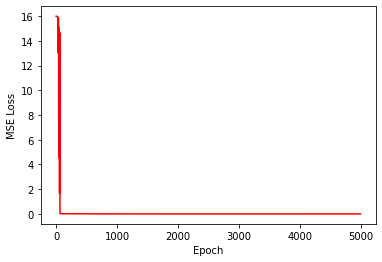

In [428]:
maj5_nn.plot()

In [429]:
Xtrain_par4 = str_arr_3d(["0000", "0001", "0010", "0011", "0100", "0101", "0110", "0111", "1000", "1001", "1010", "1011", "1100", "1101", "1110", "1111"])
Ytrain_par4 = str_to_arr("1001011001101001")

par4_nn = NN(4,1,5000,10)
par4_nn.fit(Xtrain_par4, Ytrain_par4)
print("Accuracy on the training data: ", par4_nn.predict_compare(Xtrain_par4, Ytrain_par4))

Error at epoch  0  =  7.470298528105756
Error at epoch  500  =  5.002432146653289
Error at epoch  1000  =  5.001022821329381
Error at epoch  1500  =  5.000645120856047
Error at epoch  2000  =  5.000470532071191
Error at epoch  2500  =  5.0003700837239835
Error at epoch  3000  =  5.0003048693296765
Error at epoch  3500  =  5.0002591368537335
Error at epoch  4000  =  5.000225300555103
Error at epoch  4500  =  5.000199258091453
Accuracy on the training data:  68.75


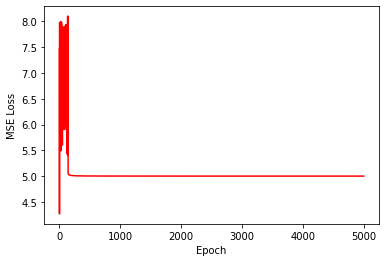

In [430]:
par4_nn.plot()

In [431]:
Xtrain_par5 = str_arr_3d(["00000", "00001", "00010", "00011", "00100", "00101", "00110", "00111", "01000", "01001", "01010", "01011", "01100", "01101", "01110", "01111", "10000", "10001", "10010", "10011", "10100", "10101", "10110", "10111", "11000", "11001", "11010", "11011", "11100", "11101", "11110", "11111"])
Ytrain_par5 = str_to_arr("10010110011010010110100110010110")

par5_nn = NN(5,1,100000,15)
par5_nn.fit(Xtrain_par5, Ytrain_par5)
print("Accuracy on the training data: ", par5_nn.predict_compare(Xtrain_par5, Ytrain_par5))

Error at epoch  0  =  15.993935392194192
Error at epoch  10000  =  15.000049992393757
Error at epoch  20000  =  15.000024329751852
Error at epoch  30000  =  15.000016490442222
Error at epoch  40000  =  15.000012622174019
Error at epoch  50000  =  15.000010274878107
Error at epoch  60000  =  15.000008681859597
Error at epoch  70000  =  15.000007523480724
Error at epoch  80000  =  15.000006640728262
Error at epoch  90000  =  15.000005944661051
Accuracy on the training data:  53.125


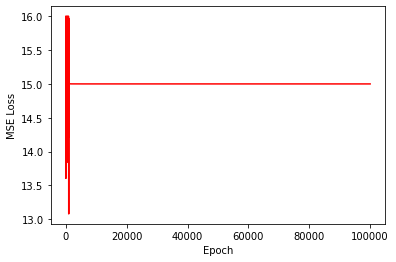

In [432]:
par5_nn.plot()